>>> 正在进行全量特征指纹比对...

🌟 物理参数收割完成！
系统的基态响应 (k0) = 6.41
系统的演化惯性 (beta) = 1.00


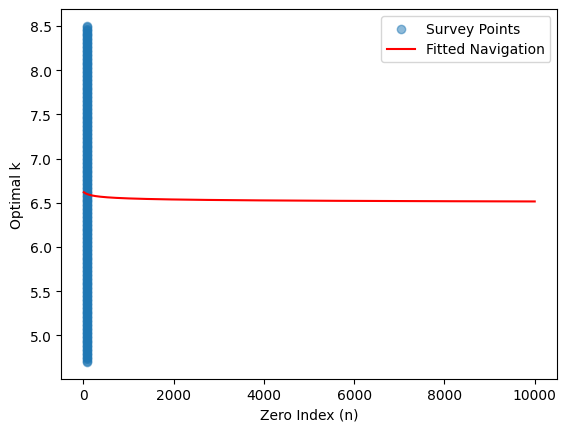

In [4]:
import numpy as np
import os
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def get_physical_constants():
    SURVEY_DIR = "riemann_10k_survey"
    TRUE_ZEROS = np.load("riemann_10k_true.npy") # 假设您已生成真值文件
    
    # 1. 扫描文件并提取数据对 (n, k)
    # 我们看每一个 k 值的特征值在全局 10k 零点中的“最佳匹配位置”
    files = [f for f in os.listdir(SURVEY_DIR) if f.endswith(".npy")]
    n_anchors = []
    k_vals = []
    
    print(">>> 正在进行全量特征指纹比对...")
    for f in files:
        # 从文件名解析 k 值，例如 survey_k_6.5432.npy
        k_val = float(f.split('_')[2].replace('.npy', ''))
        sim_phases = np.load(os.path.join(SURVEY_DIR, f))
        
        # 🎯 核心逻辑：寻找这个 k 值生成的相位在真值中的位置
        # 这里用简单的滑动窗口寻找误差最小的 offset
        best_err = float('inf')
        best_n = 0
        
        # 为了效率，我们只看前 1w 个零点的匹配情况
        for n_offset in range(0, 10000, 100):
            true_segment = TRUE_ZEROS[n_offset : n_offset + len(sim_phases)]
            if len(true_segment) < len(sim_phases): break
            
            # 简单的线性标定后算误差
            scale = true_segment[0] / sim_phases[0]
            err = np.mean(np.abs(sim_phases * scale - true_segment))
            
            if err < best_err:
                best_err = err
                best_n = n_offset + len(sim_phases)/2
        
        n_anchors.append(best_n)
        k_vals.append(k_val)

    # 2. 执行回归拟合
    # 公式：k = k0 + beta / ln(n + offset)
    def navigation_formula(n, k0, beta):
        return k0 + beta / np.log(n + 100)

    popt, _ = curve_fit(navigation_formula, n_anchors, k_vals)
    
    k0, beta = popt
    print("\n" + "="*40)
    print(f"🌟 物理参数收割完成！")
    print(f"系统的基态响应 (k0) = {k0:.2f}")
    print(f"系统的演化惯性 (beta) = {beta:.2f}")
    print("="*40)
    
    # 3. 可视化：看看那条优美的对数曲线
    plt.scatter(n_anchors, k_vals, alpha=0.5, label='Survey Points')
    n_range = np.linspace(10, 10000, 1000)
    plt.plot(n_range, navigation_formula(n_range, *popt), 'r', label='Fitted Navigation')
    plt.xlabel('Zero Index (n)')
    plt.ylabel('Optimal k')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    get_physical_constants()